In [2]:
from h5 import HDFArchive
from triqs.atom_diag import AtomDiagComplex
from triqs.operators import n, c, c_dag
from itertools import product
from triqs.plot.mpl_interface import oplot

from sort import sort_states_full
from three_pt_corr import *

In [3]:
# Hubbard dimer

####################
# Input parameters #
####################

beta = 2.0              # Inverse temperature
eps = [-1.9, -2.1]      # Energy levels of the atoms
t = 0.5                 # Hopping matrix element
U = 4.0                 # Coulomb repulsion
h_field = 0.05          # Magnetic field

spin_names = ("up", "dn")
atoms = (0, 1)

# Number of bosonic Matsubara frequencies for susceptibility calculation
n_iw = 10
# Number of fermionic Matsubara frequencies for susceptibility calculation
n_inu = 10

# Block structure of \chi^3
gf_struct = [['up', 4], ['dn', 4]]

H = sum(e * n(s, a) for (a, e), s in product(zip(atoms, eps), spin_names))
H += sum(-h_field * (n('up', a) - n('dn', a)) for a in atoms)
H += U * sum(n('up', a) * n('dn', a) for a in atoms)
H += t * sum((c_dag(sp, 0) * c(sp, 1) + c_dag(sp, 1) * c(sp, 0)) for sp in spin_names)
# H += t * sum((c_dag(sp, 2) * c(sp, 3) + c_dag(sp, 3) * c(sp, 2)) for sp in spin_names)
# H += t * sum((c_dag(sp, 0) * c(sp, 3) + c_dag(sp, 3) * c(sp, 0)) for sp in spin_names)

fops = list(product(spin_names, atoms))

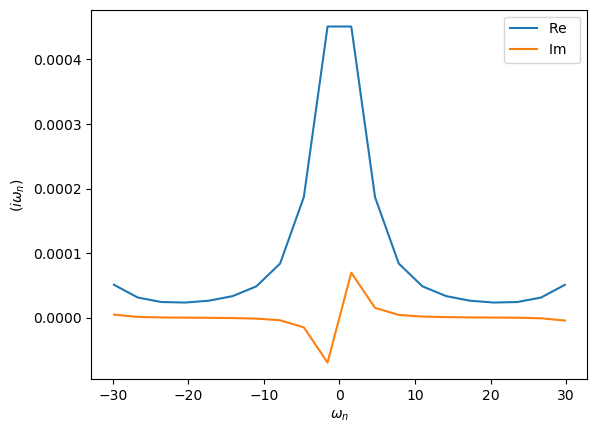

In [4]:
iw_mesh1 = MeshImFreq(beta = beta, statistic = 'Boson', n_iw = n_iw)
iw_mesh2 = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = n_inu)

G = Gf(mesh = iw_mesh2, target_shape = [])
G.zero()

ref = HDFArchive("dimer_chi3.ref.h5", 'r')
G_iw = ref["chi3_ph_AABB"]['up','up'][1,0,1,0]

for iw2 in iw_mesh2:
    for iw1 in iw_mesh1:
        G[iw2] += G_iw[iw1,iw2]

oplot(G)


In [5]:
ref["chi3_ph_AABB"]

Green's Function chi3_ph_AABB composed of 4 2-index blocks: 
 Greens Function chi3_ph_AABB_('up', 'up') with mesh Imaginary Freq Mesh with beta = 2, statistic = Boson, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false and target_shape (2, 2, 2, 2): 
 
 Greens Function chi3_ph_AABB_('up', 'dn') with mesh Imaginary Freq Mesh with beta = 2, statistic = Boson, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false and target_shape (2, 2, 2, 2): 
 
 Greens Function chi3_ph_AABB_('dn', 'up') with mesh Imaginary Freq Mesh with beta = 2, statistic = Boson, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false and target_shape (2, 2, 2, 2): 
 
 Greens Function chi3_ph_AABB_('dn', 'dn') with mesh Imaginary Freq Mesh with beta = 2, statistic = Boson, n_iw = 10, positive_only = false, Imagin

In [6]:
ad = AtomDiagComplex(H, fops)

In [7]:
eigensys = sort_states_full(spin_names, atoms, ad)

states in subspace  0 : 
| 0101 >
| 0110 >
| 1001 >
| 1010 >
states in subspace  1 : 
| 0011 >
states in subspace  2 : 
| 1100 >
states in subspace  3 : 
| 0001 >
| 0010 >
states in subspace  4 : 
| 0111 >
| 1011 >
states in subspace  5 : 
| 0100 >
| 1000 >
states in subspace  6 : 
| 1101 >
| 1110 >
states in subspace  7 : 
| 0000 >
states in subspace  8 : 
| 1111 >
Finished sorting states


In [8]:
print(eigensys[1])

[[array([1.-0.j]), ['0011']], np.float64(0.13656736447985462), 4]


In [9]:
ops = [(c_dag('up', 1), 'Fermion'),
       (c('up',0), 'Fermion'),
       (c('up', 0)*c_dag('up',1), 'Boson')]

corr = ThreePtCorr(ops = ops, hamiltonian = (ad, eigensys))

G_iw = corr.G_div_diff_iw(beta = beta, n_iw = [10,10])

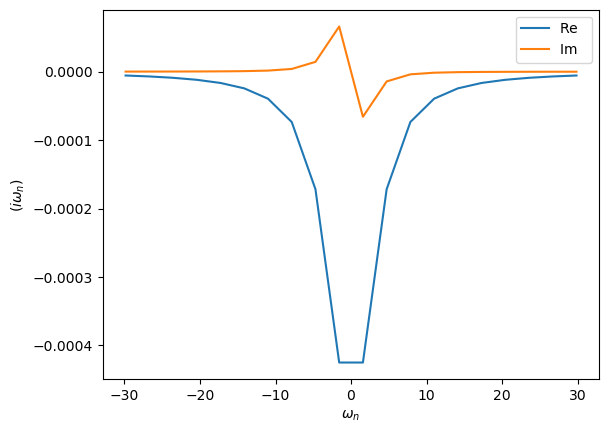

In [10]:
# G = Gf(mesh = iw_mesh2, target_shape = [])
# G.zero()

# for iw1 in iw_mesh2:
#     for iw2 in iw_mesh2:
#         G[iw1] += G_iw[iw1,iw2]



G = Gf(mesh = iw_mesh2, target_shape = [])
G.zero()

for iw2 in iw_mesh2:
    for iw1 in iw_mesh2:
        G[iw2] += G_iw[iw1,iw2]


oplot(-G)


In [11]:
G_iw

Greens Function  with mesh Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false and target_shape (): 